# (부록) LangGraph 멀티 에이전트 (Supervisor 패턴)
## LangGraph `StateGraph` 로 여러 에이전트가 협업하며 일을 분담하기

> 📦 **환경 설치·실행 명령**은 [`env_guides/M02_6_langgraph_multiagent.md`](env_guides/M02_6_langgraph_multiagent.md) 에 정리되어 있습니다.
> 이 노트북은 [`M02_5_a2a_multiagent.ipynb`](M02_5_a2a_multiagent.ipynb) 와 **같은 멀티 에이전트 실습**(계산·요약·작문 전문
> 에이전트 + 코디네이터)을, 표준 프로토콜 `a2a-sdk` 대신 **LangGraph** 로 다시 구현합니다.
> 개념 소개는 [`M02_3_mcp_a2a.ipynb`](M02_3_mcp_a2a.ipynb) 의 A2A 3패턴을 참고하세요.

---

### 왜 LangGraph 인가? (A2A 와의 차이)
[`M02_5`](M02_5_a2a_multiagent.ipynb) 의 **A2A** 는 서로 다른 프레임워크/벤더의 에이전트를 **HTTP 프로토콜**로
느슨하게 연결하는 데 강합니다(각 에이전트 = 독립 서비스). 반면 **LangGraph** 는 **하나의 프로세스 안에서**
에이전트들의 협업 흐름을 **그래프(상태 기계)** 로 명시하는 데 강합니다.

| 개념 | A2A(`M02_5`) | LangGraph(이 노트북) |
|---|---|---|
| 에이전트 = | 독립 **HTTP 서버**(AgentCard 로 발견) | 그래프의 **노드(node)** |
| 위임 방법 | A2A **메시지**(JSON-RPC) | **엣지(edge)** 를 따라 상태 전달 |
| 라우팅 | 코디네이터가 카드 보고 호출 | **조건부 엣지**(conditional edge) 로 분기 |
| 상태 공유 | 각 Task 의 Artifact | 그래프 **State**(TypedDict) 채널 |
| 강점 | 벤더 간 상호운용·분산 배포 | 순환/분기/병렬 흐름 제어·관측(stream) |

### 이 노트북이 보여줄 것
1. **역할별 전문 에이전트**(계산·요약·작문)를 LLM 기반 **그래프 노드**로 정의
2. **Planner 노드**가 복합 요청을 하위작업으로 **분해**
3. **Supervisor(조건부 엣지)** 가 각 하위작업을 알맞은 전문 노드로 **라우팅**(순환 그래프)
4. **Writer 노드**가 결과를 **한 답으로 취합** → `graph.stream()` 으로 단계별 관측
5. (보너스) **`Send` 팬아웃**으로 여러 전문 노드에 **동시(병렬) 위임**

### 전제조건
- Windows 11 + **CMD(`cmd.exe`)** + Python **3.11**(`uv` 관리), 커널 = **`Agentic AI (uv)`**
- LLM 은 `.env` 의 **`LLM_PROVIDER`** 로 결정됩니다(`utils.get_llm()`). 각 전문 에이전트(노드)의 두뇌로 이 LLM 을 사용합니다.
- `langgraph` 필요(아래 setup 셀이 자동 설치).

### 아키텍처 개요
```
[사용자 복합 요청]
        │
   ┌────▼────┐  ① 분해
   │ planner │  요청 → [{agent, subtask}, ...]
   └────┬────┘
        │  ② 조건부 라우팅(supervisor)
   ┌────▼─────────────────────────┐
   │  math_agent   research_agent │  ← 전문 노드(순환하며 하위작업 처리)
   └────┬─────────────────────────┘
        │  ③ 취합
   ┌────▼────┐
   │ writer  │  결과들 → 최종 한 단락
   └────┬────┘
        ▼
    [최종 답]
```

In [1]:
# [setup] 자기완결적 셋업 — 이 노트북만 단독 실행 가능하게 함.
import sys, os
sys.path.insert(0, os.path.abspath(''))   # notebooks/ 를 import 경로에 추가

import utils
utils.reload_env()   # .env 재로드 (LLM_PROVIDER 등 갱신)

from agentic_lib import bootstrap
from agentic_lib.bootstrap import to_text   # 공급자 무관 응답 정규화(<think> 제거 포함)

# LangGraph 멀티 에이전트에 필요한 패키지 (그래프 + LLM)
utils.uv_install(['langgraph', 'langchain', 'langchain-openai'])

llm = utils.get_llm()   # 각 전문 에이전트(그래프 노드)의 두뇌 (.env 의 LLM_PROVIDER 사용)
print("준비 완료:", utils.LLM_PROVIDER)

LLM 공급자: nvidia
  NVIDIA build Key: 설정됨  /  Model: meta/llama-3.1-8b-instruct


[uv] 설치 완료: ['langgraph', 'langchain', 'langchain-openai']


준비 완료: nvidia


---
## 1. 전문 에이전트 정의 — 역할별 시스템 프롬프트

각 전문 에이전트는 **역할을 규정하는 시스템 프롬프트 + 공용 LLM** 으로 만듭니다. A2A 버전에서
각 에이전트가 별도 HTTP 서버였다면, 여기서는 각 에이전트가 **그래프의 노드**가 됩니다.

| 에이전트(노드) | 역할(시스템 프롬프트) | 담당 |
|---|---|---|
| `math_agent` | 정확한 산술 계산 | 계산 |
| `research_agent` | 주제를 2문장 이내로 요약 | 요약 |
| `writer_agent` | 자료를 한 단락으로 정리 | 취합(작문) |

`run_specialist()` 는 역할 프롬프트로 로컬 LLM 을 호출해 응답 텍스트를 돌려주는 공용 헬퍼입니다
(`bootstrap.invoke_text` 가 `<think>` 제거 등 공급자 무관 정규화를 해 줍니다).

In [2]:
from langchain_core.messages import SystemMessage, HumanMessage

# 하위작업을 분담할 전문 에이전트(= 그래프 노드) 역할 정의
WORKER_SPECS = {
    "math_agent":     "너는 계산 전문 에이전트다. 산술 계산만 정확히 수행하고 최종 숫자만 간결히 답한다.",
    "research_agent": "너는 조사 전문 에이전트다. 주어진 주제를 2문장 이내로 쉽게 요약 설명한다.",
}
# writer_agent 는 하위작업 대상이 아니라 '최종 취합' 전용이므로 따로 둔다.
WRITER_PROMPT = "너는 작문 전문 에이전트다. 입력으로 받은 자료들을 자연스러운 한 단락으로 정리한다."


def run_specialist(system_prompt: str, user_text: str) -> str:
    '''역할 프롬프트로 로컬 LLM 을 호출해 정규화된 응답 텍스트를 돌려준다.

    A2A 버전의 LLMAgentExecutor.execute() 에 해당하는 '에이전트 본체'다.
    bootstrap.invoke_text 가 공급자 무관 정규화(<think> 제거)를 처리한다.
    '''
    return bootstrap.invoke_text(
        llm, [SystemMessage(system_prompt), HumanMessage(user_text)]
    )


# 단독 호출 데모: 계산 에이전트에게 직접 물어보기
print("math_agent 응답 :", run_specialist(WORKER_SPECS["math_agent"], "3200 곱하기 4는 얼마인가?"))

math_agent 응답 : 12800


---
## 2. 그래프 상태(State) 정의

LangGraph 는 **공유 상태(State)** 를 노드들이 읽고 갱신하며 흐릅니다. 상태는 `TypedDict` 로 선언하며,
각 키가 하나의 **채널**입니다. 노드는 갱신할 키만 담은 **부분 dict** 를 반환하면 됩니다.

| 채널 | 뜻 |
|---|---|
| `request` | 원본 사용자 복합 요청 |
| `plan` | Planner 가 만든 `[{agent, subtask}, ...]` |
| `cursor` | 다음에 처리할 `plan` 인덱스(순차 진행용) |
| `results` | 각 전문 에이전트의 `(agent, answer)` 결과 누적 |
| `final` | Writer 가 만든 최종 취합 답 |

In [3]:
from typing import TypedDict, List, Tuple, Dict


class MultiAgentState(TypedDict):
    '''코디네이터 그래프가 노드 사이로 실어 나르는 공유 상태.'''
    request: str                     # 원본 사용자 요청
    plan: List[Dict[str, str]]       # [{"agent": ..., "subtask": ...}, ...]
    cursor: int                      # 다음에 처리할 plan 인덱스
    results: List[Tuple[str, str]]   # [(agent, answer), ...] 누적
    final: str                       # 최종 취합 답변


print("상태 채널:", list(MultiAgentState.__annotations__.keys()))

상태 채널: ['request', 'plan', 'cursor', 'results', 'final']


---
## 3. Planner 노드 — 복합 요청 분해

`planner_node` 는 사용자 요청을 LLM 으로 **하위작업 목록**(어떤 전문 에이전트가 무엇을 할지)으로
분해해 상태의 `plan` 에 씁니다. 소형 모델이 JSON 형식을 어길 수 있어, **정규식 추출 + 폴백**으로
견고하게 파싱합니다(A2A 버전의 `Coordinator.decompose()` 와 동일한 전략).

In [4]:
import json, re

# 분해 대상이 되는 전문 에이전트 명단(writer 제외)
WORKER_ROSTER = "\n".join(f"- {name}: {prompt}" for name, prompt in WORKER_SPECS.items())


def planner_node(state: MultiAgentState) -> dict:
    '''사용자 요청을 [{agent, subtask}, ...] 로 분해해 상태에 기록하는 노드.'''
    sys_prompt = (
        "너는 코디네이터다. 사용자 요청을 아래 전문 에이전트가 처리할 하위작업으로 분해한다.\n"
        + WORKER_ROSTER
        + '\n반드시 JSON 배열만 출력한다. 각 원소는 {"agent": 에이전트이름, "subtask": 지시문}.'
        " 다른 설명은 쓰지 마라."
    )
    raw = bootstrap.invoke_text(llm, [SystemMessage(sys_prompt), HumanMessage(state["request"])])

    plan = []
    try:
        parsed = json.loads(re.search(r"\[.*\]", raw, re.S).group(0))
        plan = [s for s in parsed if s.get("agent") in WORKER_SPECS and s.get("subtask")]
    except Exception:
        plan = []
    if not plan:
        # 폴백: 형식 파싱 실패 시 모든 전문 에이전트에 원 요청을 그대로 위임
        plan = [{"agent": name, "subtask": state["request"]} for name in WORKER_SPECS]

    # cursor/results 를 초기화하며 계획을 상태에 기록
    return {"plan": plan, "cursor": 0, "results": []}


print("planner_node 준비 완료 — 분해 대상:", list(WORKER_SPECS.keys()))

planner_node 준비 완료 — 분해 대상: ['math_agent', 'research_agent']


---
## 4. Supervisor 라우팅 · 전문 노드 · Writer(취합) 노드

- **전문 노드**(`math_agent`/`research_agent`): 현재 `cursor` 가 가리키는 하위작업을 실행하고,
  결과를 `results` 에 추가한 뒤 `cursor` 를 1 증가시킨다.
- **Supervisor = 조건부 엣지 함수 `route()`**: 아직 처리할 하위작업이 남았으면 그 `agent` 노드로,
  다 끝났으면 `writer` 노드로 분기한다. → **순환 그래프**(worker → supervisor → worker …)를 만든다.
- **Writer 노드**: 수집된 결과를 작문 에이전트로 넘겨 **한 단락**으로 취합한다.

In [5]:
def make_worker(name: str, prompt: str):
    '''이름/역할 프롬프트를 캡처해 전문 에이전트 노드 함수를 만든다(클로저).'''
    def worker_node(state: MultiAgentState) -> dict:
        step = state["plan"][state["cursor"]]           # 지금 처리할 하위작업
        answer = run_specialist(prompt, step["subtask"])
        print(f"  [{name}] {step['subtask']}  →  {answer}")
        # 결과 누적 + 커서 전진 (다음 라우팅에서 다음 하위작업으로 넘어감)
        return {"results": state["results"] + [(name, answer)],
                "cursor": state["cursor"] + 1}
    return worker_node


def route(state: MultiAgentState) -> str:
    '''Supervisor: 남은 하위작업이 있으면 그 전문 노드로, 없으면 writer 로 분기.'''
    if state["cursor"] < len(state["plan"]):
        return state["plan"][state["cursor"]]["agent"]   # 다음 전문 노드 이름
    return "writer"


def writer_node(state: MultiAgentState) -> dict:
    '''수집된 전문 에이전트 결과들을 한 단락으로 취합하는 노드.'''
    material = "\n".join(f"- {name}: {ans}" for name, ans in state["results"])
    final = run_specialist(
        WRITER_PROMPT,
        f"아래 자료를 바탕으로 사용자 질문에 대한 최종 답을 한 단락으로 정리하라.\n"
        f"질문: {state['request']}\n자료:\n{material}",
    )
    return {"final": final}


print("노드/라우터 준비 완료:", list(WORKER_SPECS.keys()) + ["writer"])

노드/라우터 준비 완료: ['math_agent', 'research_agent', 'writer']


---
## 5. 그래프 조립 & 시각화

`StateGraph` 에 노드를 등록하고 엣지를 연결합니다.

- `START → planner` (진입)
- `planner`·각 전문 노드 → **조건부 엣지** `route` (남은 작업 있으면 해당 전문 노드, 없으면 `writer`)
- `writer → END`

조건부 엣지의 매핑(`{route 반환값: 실제 노드}`)에 **모든 전문 노드 + writer** 를 넣어야 분기가 완성됩니다.
`compile()` 후 `get_graph().draw_mermaid()` 로 그래프 구조를 확인합니다.

=== 그래프 구조 (Mermaid) ===


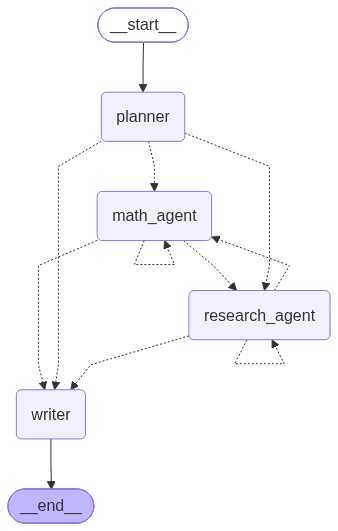

In [6]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

builder = StateGraph(MultiAgentState)

# 1) 노드 등록: planner + 전문 에이전트들 + writer
builder.add_node("planner", planner_node)
for _name, _prompt in WORKER_SPECS.items():
    builder.add_node(_name, make_worker(_name, _prompt))
builder.add_node("writer", writer_node)

# 2) 엣지 연결
builder.add_edge(START, "planner")                       # 진입 → 분해
# route 반환값(전문 노드 이름 또는 'writer')을 실제 노드로 매핑
route_map = {**{n: n for n in WORKER_SPECS}, "writer": "writer"}
builder.add_conditional_edges("planner", route, route_map)   # 분해 후 첫 라우팅
for _name in WORKER_SPECS:                                    # 각 전문 노드 실행 후 재라우팅(순환)
    builder.add_conditional_edges(_name, route, route_map)
builder.add_edge("writer", END)                          # 취합 → 종료

graph = builder.compile()

print("=== 그래프 구조 (Mermaid) ===")
# print(graph.get_graph().draw_mermaid())
display(Image(graph.get_graph().draw_mermaid_png()))

---
## 6. 실행 — 복합 요청 분해 → 라우팅 → 취합 (스트리밍 관측)

`graph.stream(state)` 는 **노드가 하나 끝날 때마다** `{노드이름: 상태갱신}` 이벤트를 흘려 줍니다.
이 덕분에 A2A 버전에서 로그로 따라가던 '분해 → 각 위임 → 취합' 과정을 **그래프 실행 흐름 그대로**
관측할 수 있습니다(LangGraph 의 큰 장점).

In [7]:
def run_graph(compiled, request: str) -> str:
    '''그래프를 스트리밍 실행하며 각 단계를 출력하고 최종 답을 반환한다.'''
    initial: MultiAgentState = {"request": request, "plan": [],
                                "cursor": 0, "results": [], "final": ""}
    final_text = ""
    for event in compiled.stream(initial):
        for node, update in event.items():
            if node == "planner":
                print("[planner] 분해된 계획:")
                for s in update["plan"]:
                    print(f"   - {s['agent']}: {s['subtask']}")
                print("-" * 60)
            elif node == "writer":
                final_text = update["final"]
    return final_text


user_request = "3200원짜리 커피 4잔의 총액을 계산하고, 에스프레소가 무엇인지 설명해줘."
final_answer = run_graph(graph, user_request)

print("\n" + "=" * 60)
print("[코디네이터 최종 답]")
print(final_answer)

[planner] 분해된 계획:
   - math_agent: 3200 * 4
   - research_agent: 에스프레소에 대해 설명
------------------------------------------------------------


  [math_agent] 3200 * 4  →  12800


  [research_agent] 에스프레소에 대해 설명  →  에스프레소는 이탈리아에서 유래한 커피의 한 종류로, 강한 맛과 풍부한 향기를 특징으로 합니다. 에스프레소는 고온의 물을 고압으로 강제로 커피콩에 통과시켜 만든 커피로, 일반적으로 1-2 oz의 양으로 서비스됩니다.



[코디네이터 최종 답]
3200원짜리 커피 4잔의 총액을 계산하면 3200 x 4 = 12800원입니다. 에스프레소는 이탈리아에서 유래한 커피의 한 종류로, 강한 맛과 풍부한 향기를 특징으로 합니다. 일반적으로 1-2 oz의 양으로 서비스됩니다.


---
## 7. (추가) `Send` 로 병렬 위임 — 팬아웃/팬인(map-reduce)

§5 의 Supervisor 그래프는 하위작업을 **순차**로 처리했습니다. 하지만 계산과 요약처럼 **서로 독립적인**
하위작업은 **동시에** 실행하는 편이 빠릅니다. LangGraph 의 **`Send`** 는 planner 가 만든 각 하위작업을
같은 `worker` 노드의 **여러 인스턴스로 동시에 전송**(팬아웃)하고, 결과는 `Annotated[list, add]` 리듀서로
**자동 취합**(팬인)합니다. 이것이 A2A 의 '각 에이전트에 병렬 위임' 을 그래프로 표현한 형태입니다.

> `results` 채널에 **리듀서(Reducer) `operator.add`** 를 달아, 병렬 노드들이 각자 낸 결과 리스트가 **합쳐지도록** 합니다.

=== 병렬 그래프 구조 (Mermaid) ===


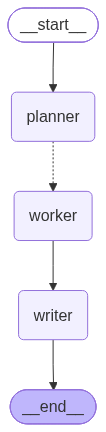


[병렬 실행]


  [병렬 math_agent] 3200 * 4 계산  →  12800


  [병렬 research_agent] 에스프레소 설명  →  에스프레소는 이탈리아에서 유래한 강한 커피의 한 종류로, 1-2ml의 커피를 25-30초 동안 9-bar의 압력을 가해 추출하는 방식으로 만든다. 에스프레소는 강한 향과 풍부한 아로마를 특징으로 하며, 일반적으로 커피숍에서 서비스되는 커피 중 하나이다.



[병렬 코디네이터 최종 답]
3200원짜리 커피 4잔의 총액은 3200 x 4 = 12800원입니다. 에스프레소는 이탈리아에서 유래한 강한 커피의 한 종류로, 강한 향과 풍부한 아로마를 특징으로 하며, 일반적으로 커피숍에서 서비스되는 커피 중 하나입니다.


In [8]:
from typing import Annotated
import operator
from langgraph.types import Send
from IPython.display import Image, display

class ParallelState(TypedDict):
    request: str
    plan: List[Dict[str, str]]
    results: Annotated[List[Tuple[str, str]], operator.add]  # 병렬 결과 자동 합침(Reducer)
    final: str


def fan_out(state: ParallelState):
    '''planner 의 각 하위작업을 worker 노드 인스턴스로 '동시에' 전송(Send 팬아웃).'''
    return [Send("worker", {"agent": s["agent"], "subtask": s["subtask"]}) for s in state["plan"]]


def worker_node(payload: dict) -> dict:
    '''Send 로 전달된 하위작업 하나를 처리하는 병렬 worker(payload = {agent, subtask}).'''
    answer = run_specialist(WORKER_SPECS[payload["agent"]], payload["subtask"])
    print(f"  [병렬 {payload['agent']}] {payload['subtask']}  →  {answer}")
    return {"results": [(payload["agent"], answer)]}   # 리듀서가 다른 worker 결과와 합침


# 병렬 그래프 조립: planner → (Send 팬아웃) → worker×N → writer
pbuilder = StateGraph(ParallelState)
pbuilder.add_node("planner", planner_node)   # 앞서 만든 planner 재사용(plan 생성)
pbuilder.add_node("worker", worker_node)
pbuilder.add_node("writer", writer_node)     # 앞서 만든 writer 재사용(취합)
pbuilder.add_edge(START, "planner")
pbuilder.add_conditional_edges("planner", fan_out, ["worker"])  # 팬아웃(병렬 분기)
pbuilder.add_edge("worker", "writer")        # 모든 worker 종료 후 취합(팬인)
pbuilder.add_edge("writer", END)
parallel_graph = pbuilder.compile()

print("=== 병렬 그래프 구조 (Mermaid) ===")
# print(parallel_graph.get_graph().draw_mermaid())
display(Image(parallel_graph.get_graph().draw_mermaid_png()))

print("\n[병렬 실행]")
p_state: ParallelState = {"request": user_request, "plan": [], "results": [], "final": ""}
p_result = parallel_graph.invoke(p_state)
print("\n" + "=" * 60)
print("[병렬 코디네이터 최종 답]")
print(p_result["final"])

---
## 8. 마무리 — LangGraph 멀티 에이전트 핵심

### 이 노트북에서 실제로 사용한 LangGraph 요소
- **`StateGraph` / `TypedDict` State** — 노드가 공유하는 상태 채널(+ `Annotated` 리듀서)
- **노드(node)** — 각 전문 에이전트/planner/writer 를 함수로 정의
- **조건부 엣지(`add_conditional_edges`)** — Supervisor 라우팅(순환 그래프)
- **`graph.stream()`** — 노드 단위 실행 관측(디버깅·트레이싱)
- **`Send`** — 하위작업 병렬 팬아웃 + 리듀서로 팬인(map-reduce)

### A2A(`M02_5`) vs LangGraph(이 노트북)
| 관점 | A2A | LangGraph |
|---|---|---|
| 결합도 | 느슨(프로세스/벤더 분리) | 단단(한 프로세스 그래프) |
| 배포 | 에이전트별 독립 서비스 | 앱 하나로 배포(각 노드는 원격 호출로 확장 가능) |
| 흐름 제어 | 코디네이터 코드 | 그래프(분기·순환·병렬)로 선언 |
| 관측 | 각 서버 로그/Task 상태 | `stream()`/체크포인터로 일괄 관측 |
| 언제? | **이종 에이전트 상호운용**이 필요할 때 | **한 팀의 협업 흐름**을 정교히 제어할 때 |

> 두 방식은 배타적이지 않습니다. 실제로는 **LangGraph 로 팀 내부 흐름**을 짜고, 팀 경계를 넘는
> 협업은 **A2A 노드**(원격 에이전트를 호출하는 그래프 노드)로 연결하는 하이브리드가 흔합니다.

### 한계 / 유의
- 로컬 소형 모델은 분해(JSON) 형식을 자주 어길 수 있어 **폴백 파서**를 두었습니다(§3).
- Supervisor 순차 그래프는 `cursor` 로 진행을 관리합니다. 하위작업이 **독립적**이면 §7 의 `Send`
  **병렬** 그래프가 지연을 줄입니다(단, 같은 로컬 LLM 에 동시 요청이 몰리는 점은 고려).
- 상태 영속화(체크포인터 `MemorySaver`/`SqliteSaver`)·휴먼인더루프·재시도 등은 LangGraph 가
  지원하며 이 노트북 범위 밖입니다. 메모리/체크포인트는 [`M04_5_memory.ipynb`](M04_5_memory.ipynb) 참고.

### 참고 자료
- LangGraph 문서: https://langchain-ai.github.io/langgraph/
- Multi-agent 개념: https://langchain-ai.github.io/langgraph/concepts/multi_agent/
- `Send`(map-reduce): https://langchain-ai.github.io/langgraph/how-tos/map-reduce/
- 표준 A2A 버전: [`M02_5_a2a_multiagent.ipynb`](M02_5_a2a_multiagent.ipynb)